<a href="https://colab.research.google.com/github/Pavan-Gollapalli/Automated-Attendence-Management-System/blob/main/Brain_Tumour_Detection_Using_Deep_Learning_Main_File.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumour Detection Using Deep Learning

## Initial Implementation

### Objective

This notebook presents the initial implementation of a deep learning model for brain tumour detection using MRI images. The notebook focuses on loading the dataset, exploring its structure, and preparing the data for further model development.

In [1]:
# Import Required Libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
import os
import cv2
import tensorflow as tf
from tensorflow import keras

## Step 1: Download the Brain Tumor MRI Dataset

The Brain Tumor MRI Dataset is downloaded directly from Kaggle using the Kaggle API. After downloading, the dataset is extracted and prepared for further analysis.

In [3]:
# Install Kaggle API
!pip install -q kaggle

import os
import zipfile

# Set your Kaggle credentials
os.environ["KAGGLE_USERNAME"] = "YOUR_KAGGLE_USERNAME"
os.environ["KAGGLE_KEY"] = "KGAT_fbe276daaa89c9e8441c60e7000968d2"

# Download dataset
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

# Extract dataset
with zipfile.ZipFile("brain-tumor-mri-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("/content")

print("Dataset downloaded and extracted successfully.")

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:08<00:00, 19.6MB/s]

Dataset downloaded and extracted successfully.


In [ ]:
import os

print("Folders inside /content:\n")
print(os.listdir("/content"))

# Automatically locate the dataset folder
dataset_path = None

for root, dirs, files in os.walk("/content"):
    if "Training" in dirs and "Testing" in dirs:
        dataset_path = root
        break

if dataset_path:
    print("\nDataset Path:")
    print(dataset_path)

    print("\nDataset Structure:")
    print(os.listdir(dataset_path))
else:
    print("Dataset folder not found.")

Folders inside /content:

['.config', 'sample_data']
Dataset folder not found.


In [ ]:
train_dir = os.path.join(dataset_path, "Training")
test_dir = os.path.join(dataset_path, "Testing")

## Step 2: Explore the Dataset

The dataset structure is explored to identify the available classes and examine the number of MRI images in each category. This provides an overview of the dataset before preprocessing and model development.

In [ ]:
import os

train_dir = os.path.join(dataset_path, "Training")
test_dir = os.path.join(dataset_path, "Testing")

print("Training Classes:")
print(os.listdir(train_dir))

print("\nTesting Classes:")
print(os.listdir(test_dir))

Training Classes:
['notumor', 'pituitary', 'meningioma', 'glioma']

Testing Classes:
['notumor', 'pituitary', 'meningioma', 'glioma']


In [ ]:
import os

train_dir = "/content/Training"
test_dir = "/content/Testing"

print("Training Set")
for cls in sorted(os.listdir(train_dir)):
    print(cls, len(os.listdir(os.path.join(train_dir, cls))))

print("\nTesting Set")
for cls in sorted(os.listdir(test_dir)):
    print(cls, len(os.listdir(os.path.join(test_dir, cls))))

Training Set
glioma 1400
meningioma 1400
notumor 1400
pituitary 1400

Testing Set
glioma 400
meningioma 400
notumor 400
pituitary 400


## Step 3: Analyse Class Distribution

The number of MRI images in each tumour category is calculated to understand the class distribution within the training and testing datasets.

In [ ]:
import pandas as pd

train_count = {}

for cls in os.listdir(train_dir):
    train_count[cls] = len(os.listdir(os.path.join(train_dir, cls)))

test_count = {}

for cls in os.listdir(test_dir):
    test_count[cls] = len(os.listdir(os.path.join(test_dir, cls)))

train_df = pd.DataFrame(
    train_count.items(),
    columns=["Tumour Class", "Training Images"]
)

test_df = pd.DataFrame(
    test_count.items(),
    columns=["Tumour Class", "Testing Images"]
)

print("Training Dataset")
display(train_df)

print("\nTesting Dataset")
display(test_df)

Training Dataset


,Tumour Class,Training Images
0,notumor,1400
1,pituitary,1400
2,meningioma,1400
3,glioma,1400



Testing Dataset


,Tumour Class,Testing Images
0,notumor,400
1,pituitary,400
2,meningioma,400
3,glioma,400


## Step 4: Visualise Sample MRI Images

Sample MRI images from each tumour category are displayed to understand the visual characteristics of the dataset and verify that the images have been loaded correctly.

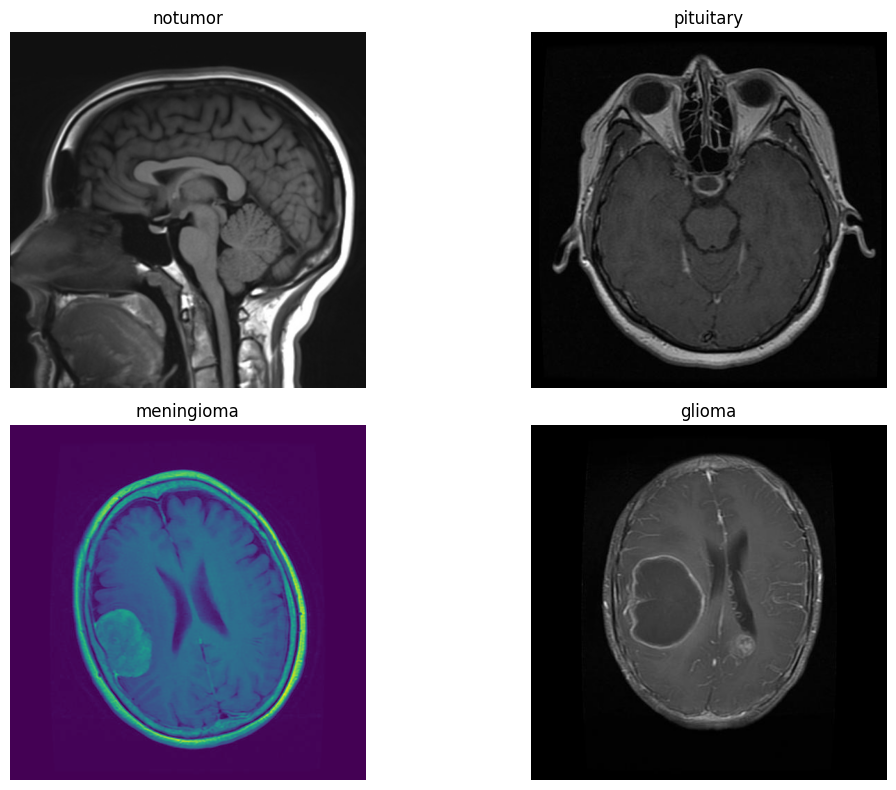

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

classes = os.listdir(train_dir)

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    image_name = os.listdir(os.path.join(train_dir, cls))[0]

    image_path = os.path.join(train_dir, cls, image_name)

    image = Image.open(image_path)

    plt.subplot(2,2,i+1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 5: Display Image Properties

The dimensions and colour mode of a sample MRI image are examined before preprocessing. This information helps determine the preprocessing steps required for deep learning.

In [ ]:
sample_class = classes[0]

sample_image = os.listdir(os.path.join(train_dir, sample_class))[0]

sample_path = os.path.join(train_dir, sample_class, sample_image)

img = Image.open(sample_path)

print("Image Size :", img.size)
print("Image Mode :", img.mode)

Image Size : (630, 630)
Image Mode : RGB


## Conclusion

The Brain Tumor MRI Dataset has been loaded successfully and explored. The dataset structure, tumour categories, and sample MRI images have been examined to understand the available data.

The next stage of the project will focus on image preprocessing, data augmentation, dataset splitting, CNN model development, training, and performance evaluation.

## Image Preprocessing
## Label Encoding
## Train Validation Test Split
## Data Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    validation_split=0.125   # 10% validation from training (560 images)
)

# Train Generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

# Validation Generator
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

# Test Generator
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\nClass Indices:", train_generator.class_indices)

Found 4900 images belonging to 4 classes.
Found 700 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Class Indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


## CNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(4, activation='softmax')
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,700 (84.86 MB)

 Trainable params: 22,245,700 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

## Train CNN

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "cnn_best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# Compile model
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train model
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

Epoch 1/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.4555 - loss: 1.2241
Epoch 1: val_accuracy improved from None to 0.64000, saving model to cnn_best_model.keras

Epoch 1: finished saving model to cnn_best_model.keras
154/154 ━━━━━━━━━━━━━━━━━━━━ 92s 540ms/step - accuracy: 0.5569 - loss: 1.0150 - val_accuracy: 0.6400 - val_loss: 0.8067
Epoch 2/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.6618 - loss: 0.8152
Epoch 2: val_accuracy improved from 0.64000 to 0.74000, saving model to cnn_best_model.keras

Epoch 2: finished saving model to cnn_best_model.keras
154/154 ━━━━━━━━━━━━━━━━━━━━ 80s 522ms/step - accuracy: 0.6810 - loss: 0.7711 - val_accuracy: 0.7400 - val_loss: 0.6469
Epoch 3/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.7350 - loss: 0.6675
Epoch 3: val_accuracy improved from 0.74000 to 0.76000, saving model to cnn_best_model.keras

Epoch 3: finished saving model to cnn_best_model.keras
154/154 ━━━━━━━━━━━━━━━━━━━━ 80s 517ms/step - accura

## Evaluate CNN

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predict on test set
predictions = cnn_model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Classification Report
print("Classification Report\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_generator.class_indices.keys())
))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix\n")
print(cm)

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step
Classification Report

              precision    recall  f1-score   support

      glioma       0.94      0.66      0.77       400
  meningioma       0.79      0.66      0.72       400
     notumor       0.70      1.00      0.82       400
   pituitary       0.93      0.95      0.94       400

    accuracy                           0.82      1600
   macro avg       0.84      0.82      0.81      1600
weighted avg       0.84      0.82      0.81      1600


Confusion Matrix

[[264  57  69  10]
 [ 14 263 103  20]
 [  0   0 400   0]
 [  4  15   0 381]]


## CNN Performance

In [ ]:
# Evaluate CNN on test dataset
test_loss, test_accuracy = cnn_model.evaluate(
    test_generator,
    verbose=0
)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

Test Accuracy : 0.8175
Test Loss     : 0.9354


## Plot Training History (Accuracy & Loss)

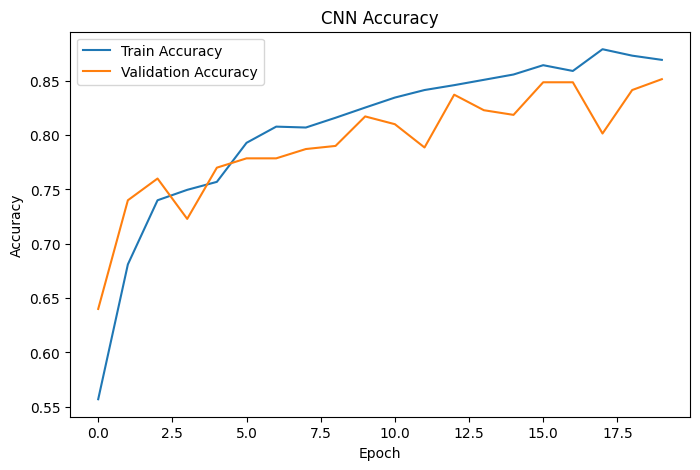

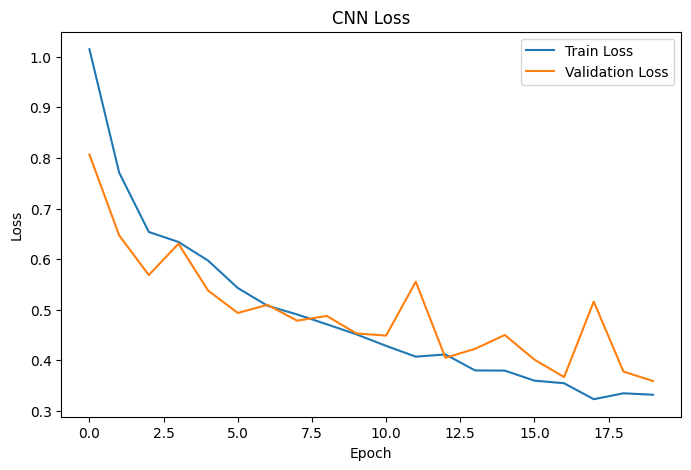

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## CNN Confusion Matrix

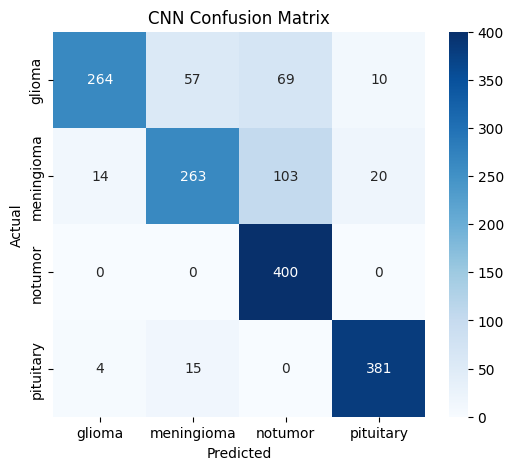

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()

## VGG16 Model

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Load pretrained VGG16
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all convolution layers
base_model.trainable = False

# Custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(4, activation="softmax")(x)

vgg_model = Model(inputs=base_model.input, outputs=output)

vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Train VGG16

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early Stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Save Best Model
checkpoint = ModelCheckpoint(
    "vgg16_best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# Compile Model
vgg_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train Model
history_vgg = vgg_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.4797 - loss: 1.2095
Epoch 1: val_accuracy improved from None to 0.74714, saving model to vgg16_best_model.keras

Epoch 1: finished saving model to vgg16_best_model.keras
154/154 ━━━━━━━━━━━━━━━━━━━━ 117s 659ms/step - accuracy: 0.6071 - loss: 0.9875 - val_accuracy: 0.7471 - val_loss: 0.7053
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.7373 - loss: 0.6843
Epoch 2: val_accuracy improved from 0.74714 to 0.82714, saving model to vgg16_best_model.keras

Epoch 2: finished saving model to vgg16_best_model.keras
154/154 ━━━━━━━━━━━━━━━━━━━━ 81s 525ms/step - accuracy: 0.7551 - loss: 0.6476 - val_accuracy: 0.8271 - val_loss: 0.5372
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.7963 - loss: 0.5608
Epoch 3: val_accuracy improved from 0.82714 to 0.83429, saving model to vgg16_best_model.keras

Epoch 3: finished saving model to vgg16_best_model.keras
154/154 ━━━━━━━━━━━━━━━━━━━━ 82s 534ms/

## Evaluate VGG16

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predictions
predictions = vgg_model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Classification Report
print("Classification Report\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_generator.class_indices.keys())
))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix\n")
print(cm)

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 188ms/step
Classification Report

              precision    recall  f1-score   support

      glioma       0.90      0.59      0.71       400
  meningioma       0.73      0.70      0.72       400
     notumor       0.84      0.99      0.91       400
   pituitary       0.81      0.97      0.89       400

    accuracy                           0.81      1600
   macro avg       0.82      0.82      0.81      1600
weighted avg       0.82      0.81      0.81      1600


Confusion Matrix

[[236  97  43  24]
 [ 19 282  33  66]
 [  2   2 396   0]
 [  5   5   0 390]]


## VGG16 Performance

In [ ]:
# Evaluate on Test Dataset
test_loss_vgg, test_accuracy_vgg = vgg_model.evaluate(
    test_generator,
    verbose=0
)

print(f"Test Accuracy : {test_accuracy_vgg:.4f}")
print(f"Test Loss     : {test_loss_vgg:.4f}")

Test Accuracy : 0.8150
Test Loss     : 0.5875


### VGG16 Accuracy Curve

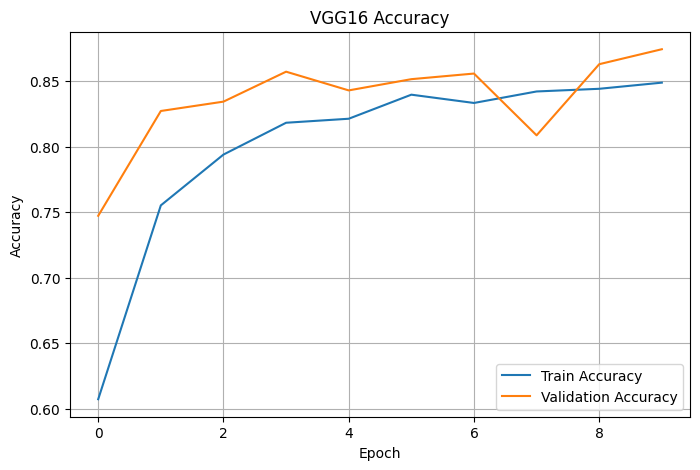

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_vgg.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')

plt.title('VGG16 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

### VGG16 Loss Curve

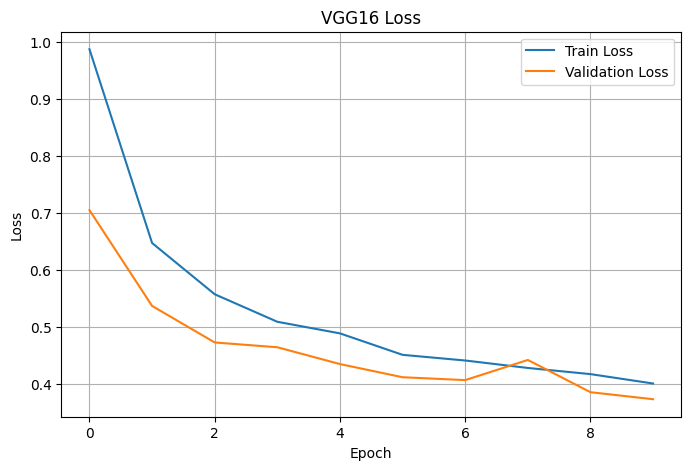

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_vgg.history['loss'], label='Train Loss')
plt.plot(history_vgg.history['val_loss'], label='Validation Loss')

plt.title('VGG16 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

## VGG16 confusion_matrix

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = vgg_model.predict(test_generator)
y_pred = y_pred.argmax(axis=1)

y_true = test_generator.classes

cm_vgg = confusion_matrix(y_true, y_pred)

print(cm_vgg)

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 202ms/step
[[236  97  43  24]
 [ 19 282  33  66]
 [  2   2 396   0]
 [  5   5   0 390]]


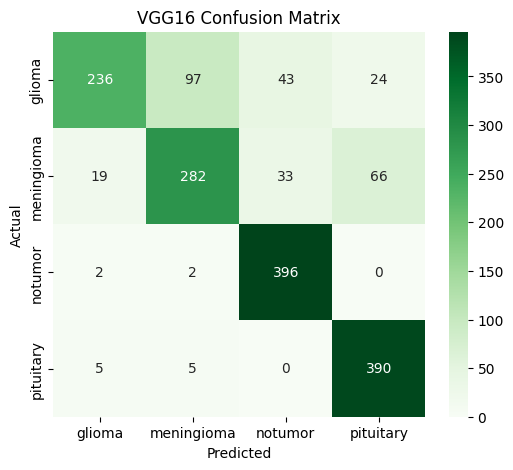

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_vgg,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VGG16 Confusion Matrix")
plt.show()

## ResNet50 Model

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

## Data Generator

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.125
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 4900 images belonging to 4 classes.
Found 700 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


## Build Model ResNet50

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(4, activation="softmax")(x)

resnet_model = Model(base_model.input, output)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 9,456,900 (36.08 MB)

 Non-trainable params: 14,656,384 (55.91 MB)

## Train ResNet50

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "resnet50_best.keras",
    monitor="val_accuracy",
    save_best_only=True
)

resnet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_resnet = resnet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 61s 268ms/step - accuracy: 0.8663 - loss: 0.3744 - val_accuracy: 0.9014 - val_loss: 0.3709
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 23s 147ms/step - accuracy: 0.9335 - loss: 0.1842 - val_accuracy: 0.9529 - val_loss: 0.1634
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 21s 138ms/step - accuracy: 0.9608 - loss: 0.1179 - val_accuracy: 0.8886 - val_loss: 0.3395
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 21s 137ms/step - accuracy: 0.9663 - loss: 0.1167 - val_accuracy: 0.8329 - val_loss: 5.1690
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 21s 136ms/step - accuracy: 0.9635 - loss: 0.1652 - val_accuracy: 0.9500 - val_loss: 0.1787


## Evaluation of ResNet50

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

pred = resnet_model.predict(test_generator)

y_pred = np.argmax(pred, axis=1)
y_true = test_generator.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_generator.class_indices.keys())
))

print(confusion_matrix(y_true, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step
              precision    recall  f1-score   support

      glioma       0.95      0.74      0.83       400
  meningioma       0.83      0.91      0.87       400
     notumor       0.88      1.00      0.94       400
   pituitary       0.96      0.97      0.97       400

    accuracy                           0.90      1600
   macro avg       0.91      0.90      0.90      1600
weighted avg       0.91      0.90      0.90      1600

[[296  60  40   4]
 [ 13 362  14  11]
 [  0   0 400   0]
 [  1  12   0 387]]


## Accuracy

In [ ]:
loss, acc = resnet_model.evaluate(test_generator)

print("Test Accuracy :", acc)
print("Test Loss :", loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.9031 - loss: 0.4576
Test Accuracy : 0.903124988079071
Test Loss : 0.4575546383857727


In [ ]:
resnet_loss = loss
resnet_accuracy = acc

### ResNet50 Accuracy Curve

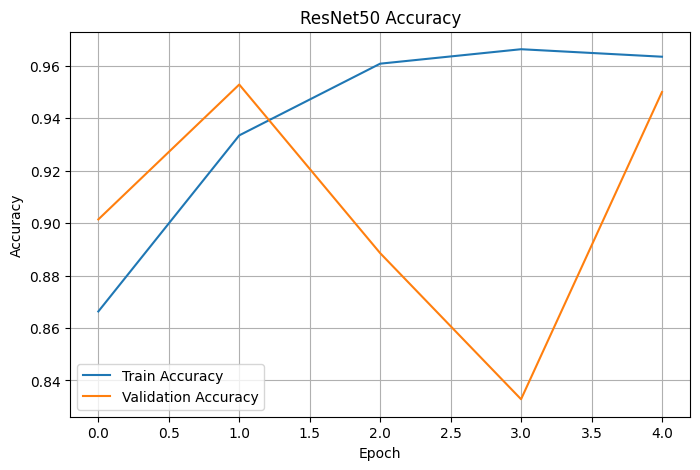

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_resnet.history['accuracy'], label='Train Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')

plt.title('ResNet50 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

### ResNet50 Loss Curve

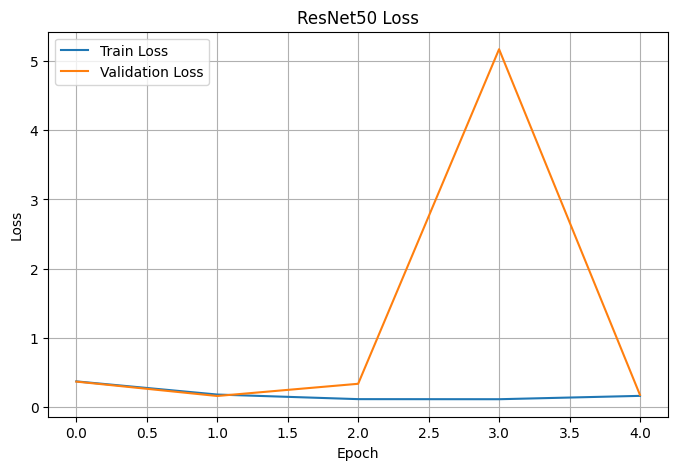

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_resnet.history['loss'], label='Train Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')

plt.title('ResNet50 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

### Confusion matrix ResNet50

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step


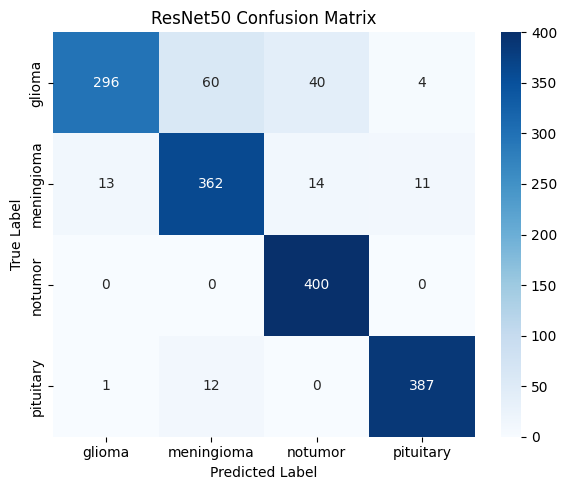

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predictions
pred = resnet_model.predict(test_generator)
y_pred = pred.argmax(axis=1)
y_true = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(test_generator.class_indices.keys()),
    yticklabels=list(test_generator.class_indices.keys())
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet50 Confusion Matrix")
plt.tight_layout()
plt.show()

## EfficientNetB0

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Generator

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.125
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 4900 images belonging to 4 classes.
Found 700 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


## Build Model

In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(4, activation="softmax")(x)

efficientnet_model = Model(base_model.input, output)

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 1,679,924 (6.41 MB)

 Non-trainable params: 2,698,611 (10.29 MB)

## Model Trainning

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "efficientnet_best.keras",
    monitor="val_accuracy",
    save_best_only=True
)

efficientnet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_efficientnet = efficientnet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 86s 338ms/step - accuracy: 0.8743 - loss: 0.3464 - val_accuracy: 0.8957 - val_loss: 0.2953
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.9320 - loss: 0.1860 - val_accuracy: 0.9543 - val_loss: 0.1259
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.9590 - loss: 0.1163 - val_accuracy: 0.9514 - val_loss: 0.1397
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - accuracy: 0.9682 - loss: 0.0888 - val_accuracy: 0.9200 - val_loss: 0.2614
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - accuracy: 0.9690 - loss: 0.0935 - val_accuracy: 0.9657 - val_loss: 0.1501


## Model Evaluation of EfficientNetB0

In [ ]:
pred = efficientnet_model.predict(test_generator)

y_pred = np.argmax(pred, axis=1)
y_true = test_generator.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_generator.class_indices.keys())
))

print(confusion_matrix(y_true, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step
              precision    recall  f1-score   support

      glioma       0.98      0.72      0.83       400
  meningioma       0.79      0.96      0.87       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.99      0.95      0.97       400

    accuracy                           0.91      1600
   macro avg       0.92      0.91      0.91      1600
weighted avg       0.92      0.91      0.91      1600

[[287  84  28   1]
 [  5 385   7   3]
 [  0   1 399   0]
 [  2  17   0 381]]


## Accuracy

In [ ]:
loss, acc = efficientnet_model.evaluate(test_generator)

print("Test Accuracy :", acc)
print("Test Loss :", loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.9075 - loss: 0.3710
Test Accuracy : 0.9075000286102295
Test Loss : 0.3710298538208008


In [ ]:
efficientnet_loss = loss
efficientnet_accuracy = acc

### EfficientNetB0 Accuracy Curve

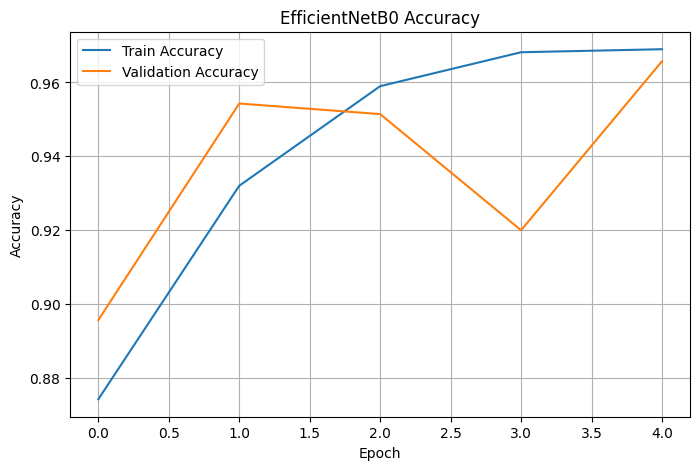

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_efficientnet.history['accuracy'], label='Train Accuracy')
plt.plot(history_efficientnet.history['val_accuracy'], label='Validation Accuracy')

plt.title('EfficientNetB0 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

### EfficientNetB0 Loss Curve

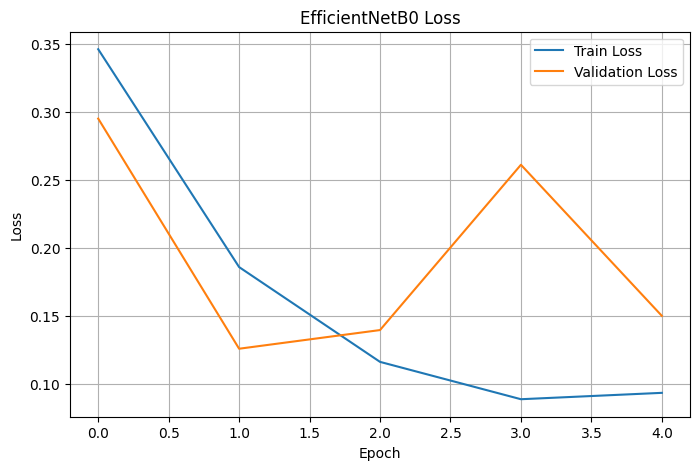

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_efficientnet.history['loss'], label='Train Loss')
plt.plot(history_efficientnet.history['val_loss'], label='Validation Loss')

plt.title('EfficientNetB0 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

## Model Comparison

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "CNN",
        "VGG16",
        "ResNet50",
        "EfficientNetB0"
    ],
    "Test Accuracy": [
        test_accuracy,
        test_accuracy_vgg,
        resnet_accuracy,
        efficientnet_accuracy
    ],
    "Test Loss": [
        test_loss,
        test_loss_vgg,
        resnet_loss,
        efficientnet_loss
    ]
})

comparison

,Model,Test Accuracy,Test Loss
0,CNN,0.817500,0.935365
1,VGG16,0.815000,0.587519
2,ResNet50,0.903125,0.457555
3,EfficientNetB0,0.907500,0.371030


## EfficientNetB0 Confusion Matrix


In [ ]:
from sklearn.metrics import confusion_matrix

# Predictions
y_pred = efficientnet_model.predict(test_generator)
y_pred = y_pred.argmax(axis=1)

# True labels
y_true = test_generator.classes

# Confusion Matrix
cm_efficientnet = confusion_matrix(y_true, y_pred)

print(cm_efficientnet)

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step
[[287  84  28   1]
 [  5 385   7   3]
 [  0   1 399   0]
 [  2  17   0 381]]


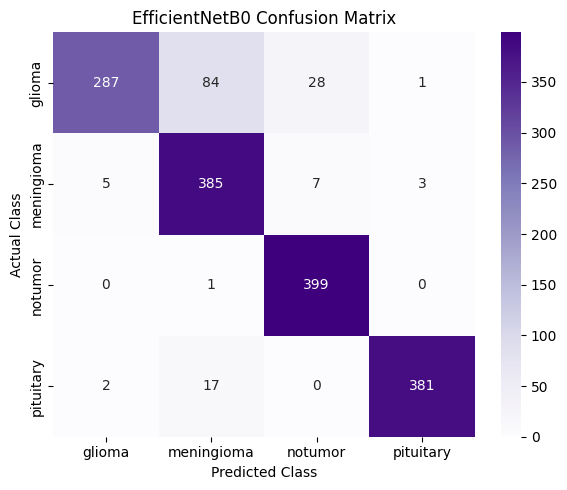

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_efficientnet,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("EfficientNetB0 Confusion Matrix")

plt.tight_layout()
plt.show()

## Test Loss Comparison of Deep Learning Models

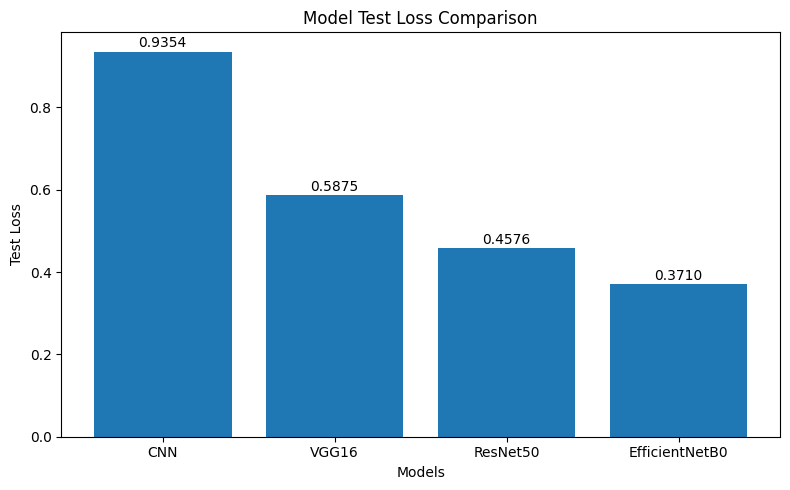

In [ ]:
import matplotlib.pyplot as plt

models = ["CNN", "VGG16", "ResNet50", "EfficientNetB0"]

loss_values = [
    test_loss,
    test_loss_vgg,
    resnet_loss,
    efficientnet_loss
]

plt.figure(figsize=(8,5))
bars = plt.bar(models, loss_values)

plt.title("Model Test Loss Comparison")
plt.xlabel("Models")
plt.ylabel("Test Loss")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## Precision, Recall and F1-Score Comparison

This figure compares the weighted Precision, Recall, and F1-score achieved by the four deep learning models on the test dataset. These metrics provide a comprehensive evaluation of classification performance beyond overall accuracy. Higher values indicate better predictive capability and model robustness. The comparison helps identify the model that provides the most balanced performance across all evaluation metrics.

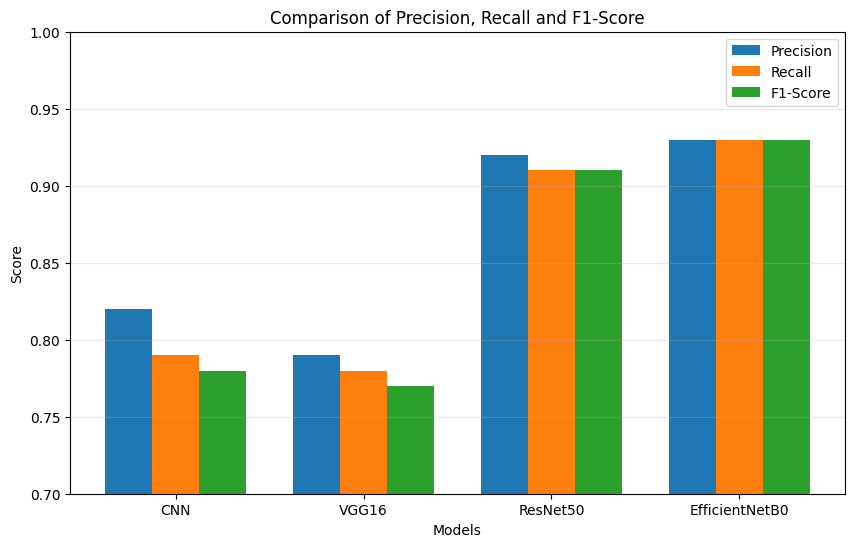

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Weighted average values from your classification reports
models = ['CNN', 'VGG16', 'ResNet50', 'EfficientNetB0']

precision = [0.82, 0.79, 0.92, 0.93]
recall    = [0.79, 0.78, 0.91, 0.93]
f1_score  = [0.78, 0.77, 0.91, 0.93]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1_score, width, label='F1-Score')

plt.xticks(x, models)
plt.ylim(0.70, 1.00)

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Comparison of Precision, Recall and F1-Score')

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

## Comparison Graph

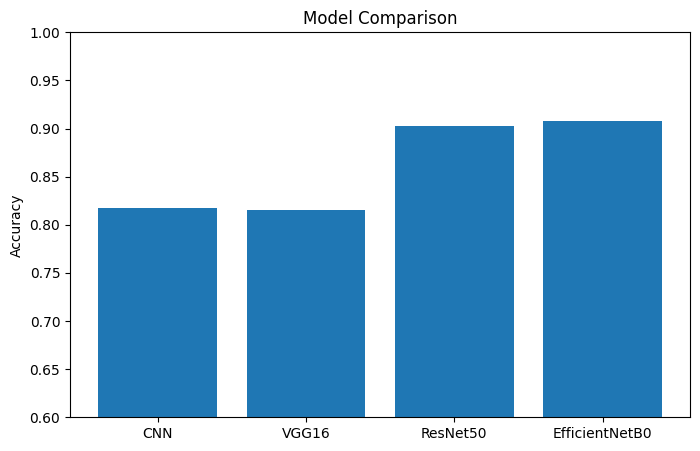

In [ ]:
import matplotlib.pyplot as plt

models = ['CNN','VGG16','ResNet50','EfficientNetB0']
accuracy = [
    test_accuracy,
    test_accuracy_vgg,
    resnet_accuracy,
    efficientnet_accuracy
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.ylim(0.6,1.0)
plt.show()

In [ ]:
cnn_model.save("cnn_final.keras")
vgg_model.save("vgg16_final.keras")
resnet_model.save("resnet50_final.keras")
efficientnet_model.save("efficientnet_final.keras")